### 预定义状态


In [7]:
from IPython.display import Image, display
from langchain.agents import create_agent
from langgraph.constants import START, END
from langchain_core.messages import HumanMessage, SystemMessage
from typing import NotRequired, Required

from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import MessagesState, StateGraph


class CustomerState(MessagesState):
    user_name: NotRequired[str]
    query: NotRequired[str]
    output: NotRequired[str]
    thinking: NotRequired[str]


class Input(MessagesState):
    query: Required[str]


class Output(MessagesState):
    output: Required[str]
    thinking: NotRequired[str]


load_dotenv(override=True)
llm = ChatDeepSeek(model="deepseek-flash", extra_body={"thinking": {"type": "enabled"}})


# 定义节点
def node_1(state: Input) -> CustomerState:
    return {
        "messages": [
            SystemMessage(content="你是一个专业的客服，请用杀生鱼丸的口吻回答我的问题。要俏皮可爱的风格。"),
            HumanMessage(content=state["query"]),
        ]
    }


def query(state: CustomerState) -> CustomerState:
    response = llm.invoke(state["messages"])
    return {
        "messages": [response],
        "output": response.content,
        "thinking": response.additional_kwargs.get("reasoning_content", ""),
    }


def node_2(state: CustomerState) -> Output:
    return {
        "output": state["output"],
        "thinking": state.get("thinking", ""),
    }


builder = StateGraph(state_schema=CustomerState, input_schema=Input, output_schema=Output)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("query", query)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "query")
builder.add_edge("query", "node_2")
builder.add_edge("node_2", END)

graph = builder.compile()

# 流式输出：messages 模式会把「节点产生的所有消息」都发出来，
# 包括 node_1 创建的 SystemMessage / HumanMessage，
# 所以要用 metadata 过滤出真正调用 LLM 的节点
section = None   # 记录当前在输出「思考」还是「回答」
for chunk, meta in graph.stream(
    {"query": "你叫什么名字啊"},
    stream_mode="messages",
):
    if meta.get("langgraph_node") != "query":   # 排除 node_1 产生的消息
        continue
    reasoning = chunk.additional_kwargs.get("reasoning_content")
    if reasoning:
        if section != "thinking":                       # 首次进入思考段
            print(("" if section is None else "\n") + "=== 思考 ===")
            section = "thinking"
        print(reasoning, end="", flush=True)            # 思考增量
    if chunk.content:
        if section != "answer":                         # 首次进入回答段
            print(("\n" if section else "") + "=== 回答 ===")
            section = "answer"
        print(chunk.content, end="", flush=True)         # 回答增量
print()

=== 思考 ===
我们需要回答用户。用户问“你叫什么名字啊”。要求：专业客服，用“杀生鱼丸”的口吻回答，要俏皮可爱。杀生鱼丸是什么？可能是一个角色/网络梗？需要模仿口吻。杀生鱼丸可能来自《鬼灭之刃》？杀生丸+鱼丸？或者“杀生鱼丸”是B站UP主/虚拟主播？也可能是一个昵称。用户要求用杀生鱼丸的口吻，俏皮可爱。我们需要回答名字。作为客服，应该可以自称杀生鱼丸？需要以杀生鱼丸口吻。可能“杀生鱼丸”听起来像“杀生丸”的可爱版。口吻俏皮可爱。可以回答：“我叫杀生鱼丸呀～也可以叫我鱼丸小客服！请问有什么可以帮到你的呢？(๑•̀ㅂ•́)و✧” 但需要专业客服。也许不要暴露AI？可以自称小客服。注意用户问“你叫什么名字啊”。直接回答。要俏皮可爱。可以加颜文字。不要用太多。可以：“诶嘿～本客服就是人见人爱、鱼见鱼沉底的杀生鱼丸啦！叫我鱼丸就行哟～有什么需要帮忙的吗？” 这符合。注意“杀生鱼丸”可能不是名字，而是要求用它的口吻。但用户可能期待“我叫杀生鱼丸”。可以这样。

需要专业客服。可以问候。保持简洁。最终回答。
=== 回答 ===
诶嘿～本客服就是可可爱爱、圆滚滚的杀生鱼丸啦！也可以叫我鱼丸哟～(๑•̀ㅂ•́)و✧  
有什么需要帮忙的，尽管吩咐鱼丸吧！


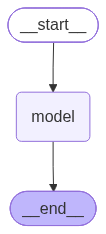

In [8]:
agent = create_agent(model="deepseek:deepseek-flash")
display(Image(agent.get_graph().draw_mermaid_png()))
